# Multi-sample metacells with batch correction

When your data has **≥2 samples / donors / batches**, computing metacells
naively is a trap: most backends partition on transcriptional similarity,
and an uncorrected embedding makes *batch* one of the strongest similarity
axes.  The result is metacells that are pure **within a batch** but never
**span** batches — useless for any cross-sample comparison.

The fix is the standard one: **correct the batch effect first**, build
metacells on the corrected embedding, and verify each metacell mixes the
samples.

This notebook:

1. Builds a controlled 2-batch dataset (so the batch effect is visible and
   the correction is verifiable).
2. Shows metacells on the **uncorrected** embedding fragmenting by batch.
3. Runs `ov.single.batch_correction` (Harmony) and rebuilds metacells on
   the corrected embedding.
4. Quantifies the improvement with a per-metacell **batch-entropy** metric.

> See [t_metacell_recommended](t_metacell_recommended.ipynb) for the
> single-sample workflow, and [zoo/index](zoo/index.md) to swap backends.

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import omicverse as ov
import scvelo as scv   # demo dataset only

ov.plot_set()

🔬 Starting plot initialization...
🧬 Detecting GPU devices…


✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.0   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 2. Build a controlled 2-batch dataset

We split the pancreas dataset into two synthetic batches and add a
**multiplicative per-gene batch effect** to batch *B* (a common, realistic
form of technical variation — different capture efficiency / sequencing
depth profile).  Using a synthetic effect means we know the ground truth:
celltype is shared, batch is technical, and a perfect metacell should mix
the two batches within each celltype.

In [2]:
adata = scv.datasets.pancreas()

# Assign each cell to batch A or B at random.
rng = np.random.default_rng(0)
adata.obs['batch'] = rng.choice(['A', 'B'], size=adata.n_obs)

# Inject a per-gene multiplicative batch effect into batch B.
import scipy.sparse as sp
batch_b = (adata.obs['batch'] == 'B').to_numpy()
gene_factor = rng.lognormal(mean=0.0, sigma=0.5, size=adata.n_vars)
X = adata.X.toarray() if sp.issparse(adata.X) else np.asarray(adata.X)
X[batch_b] = X[batch_b] * gene_factor
adata.X = sp.csr_matrix(np.rint(X))
print('batch sizes:', adata.obs['batch'].value_counts().to_dict())

batch sizes: {'B': 1900, 'A': 1796}


## 3. Preprocess and look at the uncorrected embedding

Standard omicverse flow.  We keep `batch_key='batch'` in `ov.pp.preprocess`
so HVG selection is batch-aware.

In [3]:
adata = ov.pp.qc(adata,
                 tresh={'mito_perc': 0.20, 'nUMIs': 500, 'detected_genes': 250},
                 mt_startswith='mt-')
adata = ov.pp.preprocess(adata, mode='shiftlog|pearson', n_HVGs=2000,
                         batch_key='batch')
adata.layers['lognorm'] = adata.X.copy()
adata = adata[:, adata.var.highly_variable_features]
ov.pp.scale(adata)
ov.pp.pca(adata, layer='scaled', n_pcs=30)
adata.obsm['X_pca'] = adata.obsm['scaled|original|X_pca']
ov.pp.neighbors(adata, n_neighbors=15, use_rep='X_pca')
ov.pp.umap(adata)
print('adata:', adata.shape)

🖥️ Using CPU mode for QC...

📊 Step 1: Calculating QC Metrics

   ✓ Gene Family Detection:
   ┌──────────────────────────────┬────────────────────┬────────────────────┐
   │ Gene Family                  │ Genes Found        │ Detection Method   │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Mitochondrial                │ 13                 │ Auto (MT-)         │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Ribosomal                    │ 0 ⚠️               │ Auto (RPS/RPL)     │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Hemoglobin                   │ 0 ⚠️               │ Auto (regex)       │
   └──────────────────────────────┴────────────────────┴────────────────────┘



   ✓ QC Metrics Summary:
   ┌─────────────────────────┬────────────────────┬─────────────────────────┐
   │ Metric                  │ Mean               │ Range (Min - Max)       │
   ├─────────────────────────┼────────────────────┼─────────────────────────┤
   │ nUMIs                   │ 7359               │ 3173 - 20461            │
   ├─────────────────────────┼────────────────────┼─────────────────────────┤
   │ Detected Genes          │ 2453               │ 1421 - 4492             │
   ├─────────────────────────┼────────────────────┼─────────────────────────┤
   │ Mitochondrial %         │ 0.7%               │ 0.2% - 4.3%             │
   ├─────────────────────────┼────────────────────┼─────────────────────────┤
   │ Ribosomal %             │ 0.0%               │ 0.0% - 0.0%             │
   ├─────────────────────────┼────────────────────┼─────────────────────────┤
   │ Hemoglobin %            │ 0.0%               │ 0.0% - 0.0%             │
   └─────────────────────────┴────────

   ✓ Final filtering: 0 cells, 12,347 genes removed

🔍 Step 4: Doublet Detection
   💡 Running pyscdblfinder (Python port of R scDblFinder)
   🔍 Running scdblfinder detection...


[ScDblFinder] wrote scDblFinder_score + scDblFinder_class — threshold=0.181
   ✓ scDblFinder completed: 66 doublets removed (1.8%)



╭─ SUMMARY: qc ──────────────────────────────────────────────────────╮
│  Duration: 16.2546s                                                │
│  Shape:    3,696 x 27,998 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ cell_complexity (float)                              │
│           │ ✚ detected_genes (int)                                 │
│           │ ✚ hb_perc (float)                                      │
│           │ ✚ mito_perc (float)                                    │
│           │ ✚ nUMIs (float)                                        │
│           │ ✚ n_counts (float)                                     │
│           │ ✚ n_genes (int)                                        │
│           │ ✚ n_genes_by_counts (int)                              │
│    

...


╭─ SUMMARY: scale ───────────────────────────────────────────────────╮
│  Duration: 0.6615s                                                 │
│  Shape:    3,630 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● LAYERS │ ✚ scaled (array, 3630x2000)                            │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
computing PCA🔍
    with n_comps=30
   🖥️ Using sklearn PCA for CPU computation
   🖥️ sklearn PCA backend: CPU computation
   📊 PCA input data type: ArrayView, shape: (3630, 2000), dtype: float64


   🔧 PCA solver used: covariance_eigh
    finished✅ (1.63s)

╭─ SUMMARY: pca ─────────────────────────────────────────────────────╮
│  Duration: 1.6377s                                                 │
│  Shape:    3,630 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ scaled|original|cum_sum_eigenvalues                  │
│           │ ✚ scaled|original|pca_var_ratios                       │
│                                                                    │
│  ● OBSM   │ ✚ scaled|original|X_pca (array, 3630x30)               │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
🖥️ Using Scanpy CPU to calculate neighbors...

🔍 K-Nearest Neighbors Graph Construction

   🔍 Computing connectivity matrix...
   💡 Using UMAP-style connectivity


   ✓ Graph is fully connected

✅ KNN Graph Construction Completed Successfully!
   ✓ Processed: 3,630 cells with 15 neighbors each
   ✓ Results added to AnnData object:
     • 'neighbors': Neighbors metadata (adata.uns)
     • 'distances': Distance matrix (adata.obsp)
     • 'connectivities': Connectivity matrix (adata.obsp)

╭─ SUMMARY: neighbors ───────────────────────────────────────────────╮
│  Duration: 8.2358s                                                 │
│  Shape:    3,630 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
╰────────────────────────────────────────────────────────────────────╯
🔍 [2026-05-19 18:13:01] Running UMAP in 'cpu' mode...
🖥️ Using Scanpy CPU UMAP...

🔍 UMAP Dimensionality Reduction:
   Mode: cpu
   Method: umap
   Components: 2
   Min distan


✅ UMAP Dimensionality Reduction Completed Successfully!
   ✓ Embedding shape: 3,630 cells × 2 dimensions
   ✓ Results added to AnnData object:
     • 'X_umap': UMAP coordinates (adata.obsm)
     • 'umap': UMAP parameters (adata.uns)
✅ UMAP completed successfully.

╭─ SUMMARY: umap ────────────────────────────────────────────────────╮
│  Duration: 1.092s                                                  │
│  Shape:    3,630 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ umap                                                 │
│           │ └─ params: {'a': 0.5830300199950147, 'b': 1.334166993228519}│
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
adata: (3630, 2000)

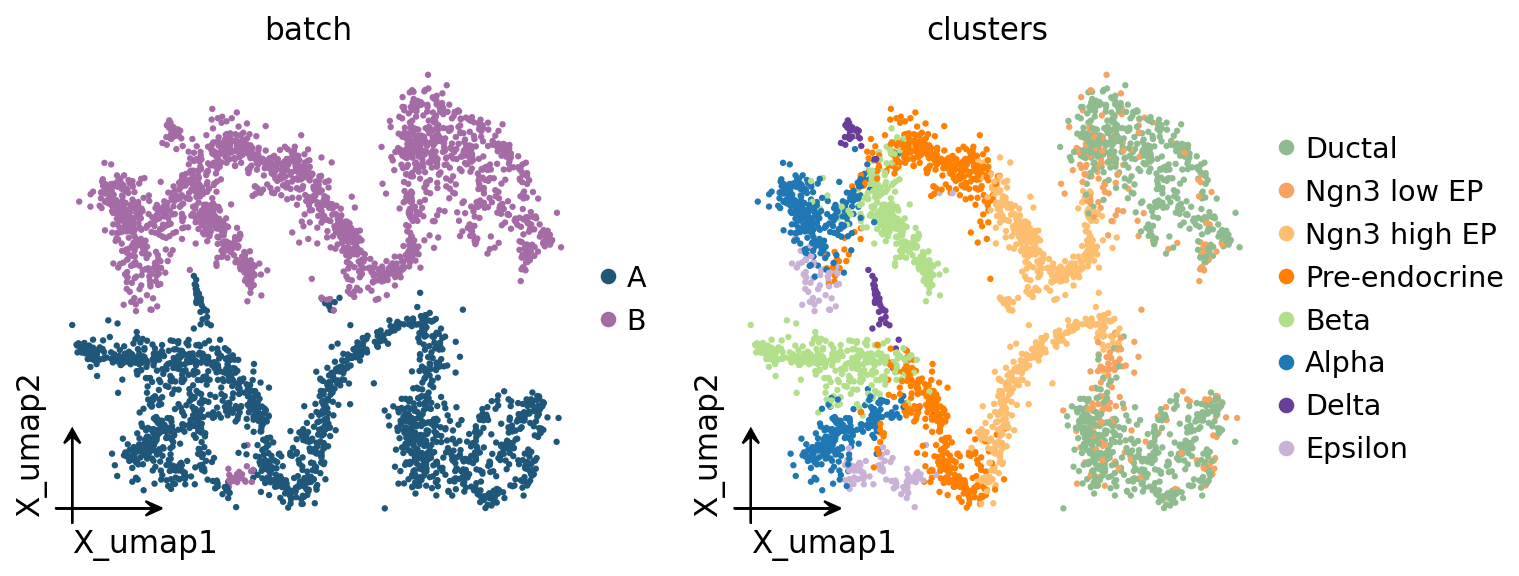

In [4]:
# Uncorrected UMAP: colour by batch (should show separation) and by celltype.
ov.pl.embedding(adata, basis='X_umap', color=['batch', 'clusters'],
                frameon='small', wspace=0.5)

## 4. Naive metacells on the uncorrected embedding

Build SEACells metacells directly on `X_pca` (uncorrected).  We then measure
**batch entropy** per metacell — the Shannon entropy of its batch
composition, normalised to [0, 1].  A metacell that mixes both batches
50/50 has entropy 1.0; a metacell that is 100 % one batch has entropy 0.0.

In [5]:
mc_naive = ov.single.MetaCell(
    adata.copy(), method='seacells', n_metacells=adata.n_obs // 50,
    use_rep='X_pca', device='cpu', random_state=0,
).fit()
print(f'naive fit done: n_metacells={mc_naive.n_metacells}')

Welcome to SEACells!


  0%|          | 0/3630 [00:00<?, ?it/s]

Parameter graph_construction = union being used to build KNN graph...


  0%|          | 0/3630 [00:00<?, ?it/s]

  0%|          | 0/3630 [00:00<?, ?it/s]

Building kernel on X_pca


  0%|                                                                                                                      | 0/11 [00:00<?, ?it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 549.37it/s]

naive fit done: n_metacells=72


In [6]:
# Per-metacell batch entropy. Helper kept inline — it is 6 lines and
# specific to this tutorial's synthetic 2-batch design.
def batch_entropy(mc, batch_key='batch'):
    labels = mc._fit_result.assignments
    batch = mc.adata.obs[batch_key].to_numpy()
    ent = []
    for u in np.unique(labels):
        b = batch[labels == u]
        _, cnt = np.unique(b, return_counts=True)
        p = cnt / cnt.sum()
        h = -(p * np.log(p)).sum() / np.log(len(p)) if len(p) > 1 else 0.0
        ent.append(h)
    return np.array(ent)

ent_naive = batch_entropy(mc_naive)
print(f'naive metacells — mean batch entropy: {ent_naive.mean():.3f}')
print(f'  fraction of single-batch metacells: {(ent_naive < 0.1).mean():.2%}')

naive metacells — mean batch entropy: 0.043
  fraction of single-batch metacells: 93.06%


## 5. Correct the batch effect with Harmony

`ov.single.batch_correction` writes a corrected embedding into
`adata.obsm['X_harmony']`.  Harmony is the CPU-friendly default; for GPU
environments `scVI` / `CONCORD` give stronger correction (see
[t_single_batch](../t_single_batch.ipynb)).

In [7]:
ov.single.batch_correction(adata, batch_key='batch',
                           methods='harmony', n_pcs=30)
print('corrected embedding keys:',
      [k for k in adata.obsm if 'harmony' in k.lower()])

...Begin using harmony to correct batch effect
🚀 Using PyTorch CUDA acceleration for Harmony
    Data: 30 PCs × 3630 cells
    Batch variables: ['batch']
    Max iterations: 10
    Convergence threshold: 0.0001


    Initializing centroids (K=100) ... 

done


🔍 [2026-05-19 18:13:21] Running Harmony integration...


Harmony iterations:   0%|                                                                                                  | 0/10 [00:00<?, ?it/s]

...

Harmony iteration 2/10:  10%|████████▌                                                                             | 1/10 [00:00<00:03,  2.80it/s]

Harmony iteration 3/10:  10%|████████▌                                                                             | 1/10 [00:00<00:03,  2.80it/s]

Harmony converged after 3 iterations:  10%|███████▏                                                                | 1/10 [00:00<00:03,  2.80it/s]

Harmony converged after 3 iterations:  20%|██████████████▍                                                         | 2/10 [00:00<00:02,  3.89it/s]


✅ Harmony converged after 3 iterations

╭─ SUMMARY: batch_correction ────────────────────────────────────────╮
│  Duration: 1.2792s                                                 │
│  Shape:    3,630 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ X_harmony (array, 3630x30)                           │
│           │ ✚ X_pca_harmony (array, 3630x30)                       │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
corrected embedding keys: ['X_pca_harmony', 'X_harmony']


🖥️ Using Scanpy CPU to calculate neighbors...

🔍 K-Nearest Neighbors Graph Construction:
   Mode: cpu
   Neighbors: 15
   Method: umap
   Metric: euclidean
   Representation: X_harmony
   🔍 Computing neighbor distances...


   🔍 Computing connectivity matrix...
   💡 Using UMAP-style connectivity
   ✓ Graph is fully connected

✅ KNN Graph Construction Completed Successfully!
   ✓ Processed: 3,630 cells with 15 neighbors each
   ✓ Results added to AnnData object:
     • 'neighbors': Neighbors metadata (adata.uns)
     • 'distances': Distance matrix (adata.obsp)
     • 'connectivities': Connectivity matrix (adata.obsp)

╭─ SUMMARY: neighbors ───────────────────────────────────────────────╮
│  Duration: 0.3395s                                                 │
│  Shape:    3,630 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
╰────────────────────────────────────────────────────────────────────╯
🔍 [2026-05-19 18:13:22] Running UMAP in 'cpu' mode...
🖥️ Using Scanpy CPU UMAP...

🔍 UMAP Dimensionali


✅ UMAP Dimensionality Reduction Completed Successfully!
   ✓ Embedding shape: 3,630 cells × 2 dimensions
   ✓ Results added to AnnData object:
     • 'X_umap': UMAP coordinates (adata.obsm)
     • 'umap': UMAP parameters (adata.uns)
✅ UMAP completed successfully.

╭─ SUMMARY: umap ────────────────────────────────────────────────────╮
│  Duration: 0.2219s                                                 │
│  Shape:    3,630 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
╰────────────────────────────────────────────────────────────────────╯


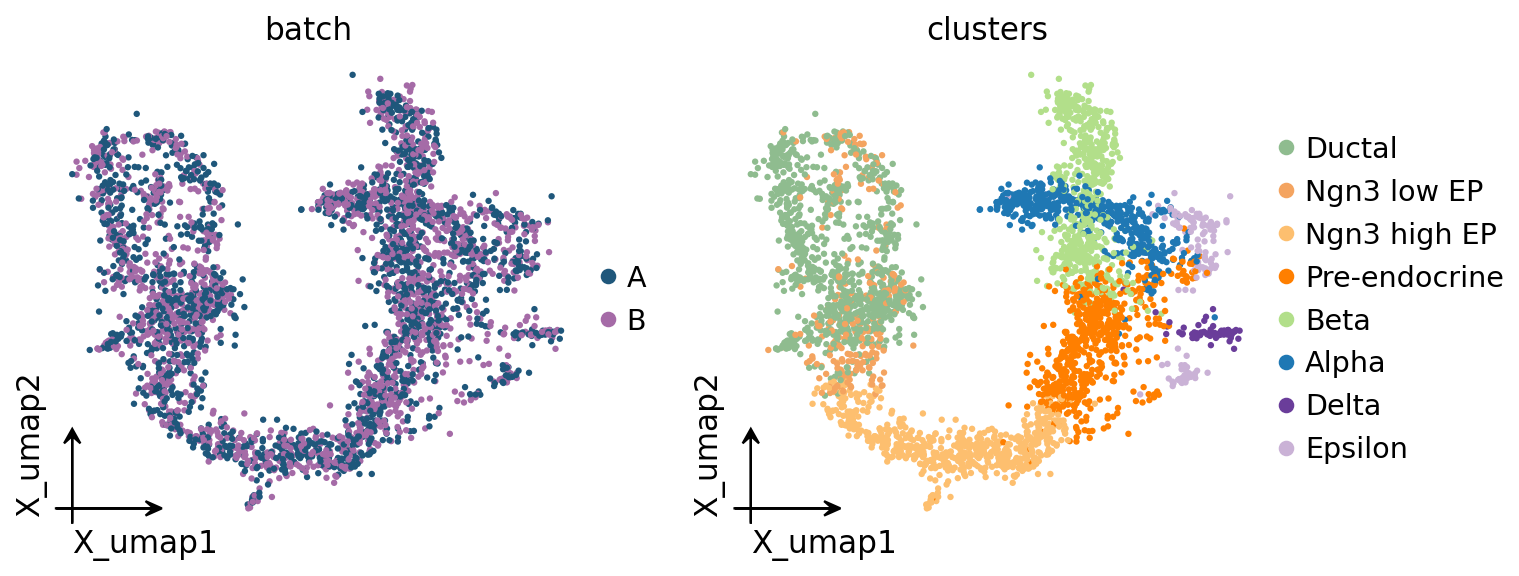

In [8]:
# Recompute neighbors + UMAP on the corrected embedding to visualise.
ov.pp.neighbors(adata, n_neighbors=15, use_rep='X_harmony')
ov.pp.umap(adata)
ov.pl.embedding(adata, basis='X_umap', color=['batch', 'clusters'],
                frameon='small', wspace=0.5)

## 6. Metacells on the corrected embedding

Same backend, same `n_metacells` — only `use_rep` changes from `X_pca` to
`X_harmony`.  This is the one-line difference that makes metacells
multi-sample-aware.

In [9]:
mc_corrected = ov.single.MetaCell(
    adata.copy(), method='seacells', n_metacells=adata.n_obs // 50,
    use_rep='X_harmony', device='cpu', random_state=0,
).fit()

ent_corrected = batch_entropy(mc_corrected)
print(f'corrected metacells — mean batch entropy: {ent_corrected.mean():.3f}')
print(f'  fraction of single-batch metacells: {(ent_corrected < 0.1).mean():.2%}')

Welcome to SEACells!


  0%|          | 0/3630 [00:00<?, ?it/s]

Parameter graph_construction = union being used to build KNN graph...


  0%|          | 0/3630 [00:00<?, ?it/s]

  0%|          | 0/3630 [00:00<?, ?it/s]

Building kernel on X_harmony


  0%|                                                                                                                      | 0/15 [00:00<?, ?it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [00:00<00:00, 468.47it/s]

corrected metacells — mean batch entropy: 0.992
  fraction of single-batch metacells: 0.00%


## 7. Before / after: batch-entropy distribution

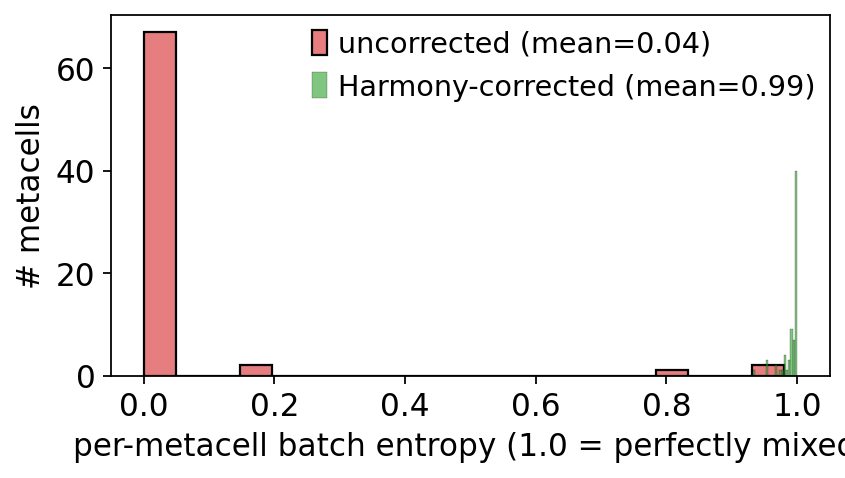

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(figsize=(5.5, 3.2))
sns.histplot(ent_naive,     bins=20, ax=ax, color='#d62728',
             label=f'uncorrected (mean={ent_naive.mean():.2f})', alpha=0.6)
sns.histplot(ent_corrected, bins=20, ax=ax, color='#2ca02c',
             label=f'Harmony-corrected (mean={ent_corrected.mean():.2f})', alpha=0.6)
ax.set_xlabel('per-metacell batch entropy (1.0 = perfectly mixed)')
ax.set_ylabel('# metacells')
ax.legend()
plt.tight_layout(); plt.show()

## 8. Did we keep celltype purity?

Batch mixing is only useful if celltype purity survives.  A good correction
**raises batch entropy without lowering celltype purity** — the metacells
should still each be one cell state.

In [11]:
p_naive     = mc_naive.compute_purity('clusters').purity.mean()
p_corrected = mc_corrected.compute_purity('clusters').purity.mean()
summary = pd.DataFrame({
    'mean_batch_entropy': [ent_naive.mean(), ent_corrected.mean()],
    'mean_celltype_purity': [p_naive, p_corrected],
}, index=['uncorrected (X_pca)', 'Harmony (X_harmony)'])
summary.round(3)

,mean_batch_entropy,mean_celltype_purity
uncorrected (X_pca),0.043,0.868
Harmony (X_harmony),0.992,0.866


## 9. UMAP: corrected metacell centroids

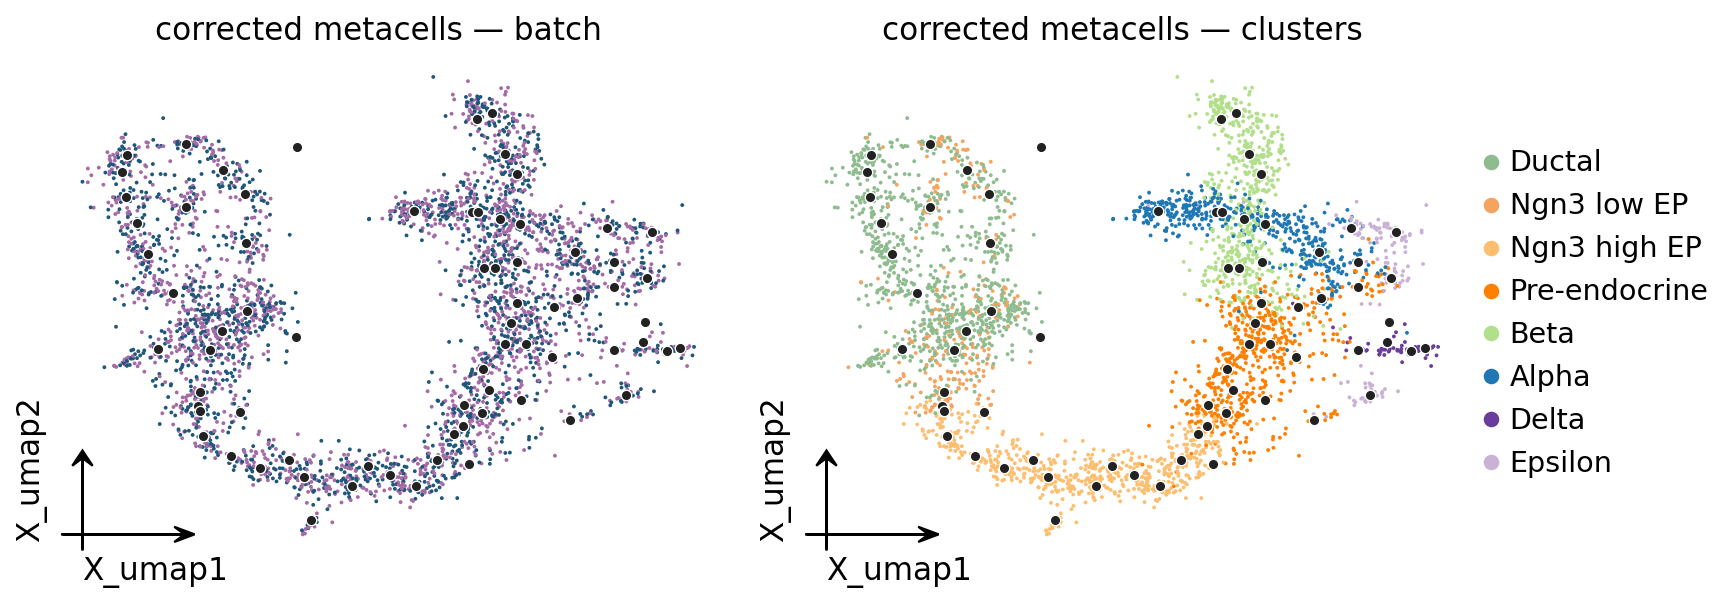

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for axi, color in zip(ax, ['batch', 'clusters']):
    ov.pl.embedding(mc_corrected.adata, basis='X_umap', color=color, ax=axi,
                    show=False, frameon='small',
                    title=f'corrected metacells — {color}', size=12,
                    legend_loc='right margin' if color == 'clusters' else None)
    labels = mc_corrected._fit_result.assignments
    pts = np.array([mc_corrected.adata.obsm['X_umap'][labels == u].mean(axis=0)
                    for u in np.unique(labels)])
    axi.scatter(pts[:, 0], pts[:, 1], s=22, c='#222',
                edgecolors='white', linewidths=0.6, zorder=5)
plt.tight_layout(); plt.show()

## 10. Aggregate + cross-sample use

The corrected metacell AnnData is now suitable for cross-sample work.  Two
common patterns:

- **Metacell-level analysis** (state granularity): pass `ad_mc` straight
  into CCC / SCENIC / trajectory.
- **Pseudobulk per (metacell-type × sample)**: aggregate once more by
  `(clusters, batch)` for a cohort-level DE model — this is where metacell
  and pseudobulk *compose*.

In [13]:
ad_mc = mc_corrected.predicted(method='soft', layer='counts', summary='sum',
                              celltype_label='clusters')
# Propagate the majority batch onto each metacell for downstream grouping.
ov.single.get_obs_value(ad_mc, mc_corrected.adata, groupby='batch', type='str')
print(f'metacell AnnData: {ad_mc.shape}')
print('per-metacell batch composition (first 5):')
ad_mc.obs[['n_cells', 'clusters', 'clusters_purity', 'batch']].head()

... batch added to ad.obs[batch]
metacell AnnData: (72, 2000)
per-metacell batch composition (first 5):


,n_cells,clusters,clusters_purity,batch
mc-0,231,Alpha,0.961905,B
mc-1,40,Delta,1.000000,B
mc-2,92,Beta,1.000000,A
mc-3,254,Ductal,0.564815,B
mc-4,38,Pre-endocrine,0.550725,B


## 11. Takeaways

- **Never build metacells on an uncorrected embedding when you have
  multiple samples.**  Batch becomes a dominant similarity axis and your
  metacells will be single-batch — the histogram in section 7 makes this
  concrete.
- The fix is one line: `ov.single.batch_correction(...)` then point
  `MetaCell(use_rep='X_harmony')` at the corrected embedding.
- Always check **both** axes after correction: batch entropy should go *up*
  and celltype purity should *not* go down (section 8).
- `metaq` is batch-aware in a different way — its `multimodal` capability
  lets you feed multiple omics, and the encoder can be trained on a
  batch-balanced loader.  For pure scRNA-seq multi-sample, the
  Harmony-then-metacell recipe here is the simplest robust choice.
- To go from metacells to a **cohort-level DE model**, aggregate once more
  per `(metacell-celltype × sample)` — that pseudobulk-of-metacells is the
  correct unit for `expression ~ condition` testing (see the
  [section index](index.md) for the metacell-vs-pseudobulk distinction).